In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy as sp
import sklearn
import statsmodels.api as sm



pd.set_option('display.max_columns', None)

from stat_utils import statistical_tests_step1
from utils import plot_dataframe

In [17]:
dir(pd)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [18]:
help(plot_dataframe)

Help on function plot_dataframe in module utils:

plot_dataframe(
    df: pandas.core.frame.DataFrame,
    color_column: str = None,
    save_dir: str = None,
    create_dashboard: bool = True
) -> None
    Generate and display count plots or histograms for all columns in the DataFrame.

    - If color_column is numerical: treats it as a target and creates plots showing
      the relationship between the target and each other column using plot_numerical_target
    - If color_column is categorical: uses it for grouping/faceting in count plots and histograms
    - If no color_column: generates simple histograms for numeric and count plots for categorical

    Parameters
    ----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    color_column : str, optional
        Optional column name to use for color (grouping) or as a numerical target.
    save_dir : str, optional
        If provided, the directory where plots will be saved as HTML files.
    create_dashboa

In [20]:
df = pd.read_csv("artifacts/train_data.csv")

1. 도메인 접근
2. 통계적 접근

분석 컬럼

```
'잔액_리볼빙일시불이월_B0M', '잔액_리볼빙일시불이월_target', '월중평잔_RV일시불', 'RV약정청구율', 'RV최소결제비율',
"잔액_일시불_B0M", "잔액_할부_B0M", "잔액_현금서비스_B0M", "잔액_리볼빙일시불이월_B0M", "잔액_리볼빙CA이월_B0M", '잔액_카드론_B0M', '잔액_신판평균한도소진율_r3m', '연체일수_B1M', '잔액_일시불_B0M', '이용건수_신용_B0M', '연체원금_B1M', 'RV신청일자', '이용금액_해외', '이용금액_요식', '회원여부_연체', 'RV_평균잔액_R3M', '연체잔액_RV일시불_B0M', '이용금액_연체_B0M', '이용금액_일시불_B0M', '이용금액_신용_B0M', '카드이용한도금액', '연령', 'VIP등급코드', '최상위카드등급코드', 'Life_Stage'
```

In [21]:
# 잔액 관련
df["잔액_일시불_B0M_B1M_ratio"] = df["잔액_일시불_B0M"] / df["잔액_일시불_B1M"]
df["잔액_할부_B0M_B1M_ratio"] = df["잔액_할부_B0M"] / df["잔액_할부_B1M"]
df["잔액_현금서비스_B0M_B1M_ratio"] = df["잔액_현금서비스_B0M"] / df["잔액_현금서비스_B1M"]
df["잔액_카드론_B0M_B1M_ratio"] = df["잔액_카드론_B0M"] / df["잔액_카드론_B1M"]

# 연체일수 및 원금 관련
df["연체일수_B1M_B2M_ratio"] = df["연체일수_B1M"] / df["연체일수_B2M"]
df["연체원금_B1M_B2M_ratio"] = df["연체원금_B1M"] / df["연체원금_B2M"]

# (필요시, B2M도 함께 계산)
df["잔액_일시불_B1M_B2M_ratio"] = df["잔액_일시불_B1M"] / df["잔액_일시불_B2M"]
df["잔액_할부_B1M_B2M_ratio"] = df["잔액_할부_B1M"] / df["잔액_할부_B2M"]
df["잔액_현금서비스_B1M_B2M_ratio"] = df["잔액_현금서비스_B1M"] / df["잔액_현금서비스_B2M"]
df["잔액_카드론_B1M_B2M_ratio"] = df["잔액_카드론_B1M"] / df["잔액_카드론_B2M"]

In [22]:
outputs = plot_dataframe(df[[i for i in df.columns if 'ratio' in i]], save_dir='viz')

Dashboard created: viz\dashboard.html
Open this file in your browser to view all 10 plots


In [23]:
target = "잔액_리볼빙일시불이월_target"
df.head(1)

,발급회원번호,남녀구분코드,연령,VIP등급코드,최상위카드등급코드,회원여부_이용가능,회원여부_이용가능_CA,회원여부_이용가능_카드론,소지여부_신용,회원여부_연체,이용거절여부_카드론,이용금액_R3M_신용,이용금액_R3M_체크,이용금액_R3M_신용_가족,이용금액_R3M_체크_가족,보유여부_해외겸용_본인,이용가능여부_해외겸용_본인,이용여부_3M_해외겸용_본인,거주시도명,직장시도명,가입통신회사코드,Life_Stage,최종카드발급경과월,최초한도금액,카드이용한도금액,CA한도금액,일시상환론한도금액,월상환론한도금액,CA이자율_할인전,CL이자율_할인전,RV일시불이자율_할인전,RV현금서비스이자율_할인전,자발한도감액횟수_R12M,자발한도감액금액_R12M,강제한도감액횟수_R12M,강제한도감액금액_R12M,한도증액횟수_R12M,한도증액금액_R12M,상향가능한도금액,상향가능CA한도금액,월상환론상향가능한도금액,RV신청일자,RV약정청구율,RV최소결제비율,RV전환가능여부,일시불ONLY전환가능여부,시장단기연체여부_R6M,시장단기연체여부_R3M,시장연체상환여부_R6M,시장연체상환여부_R3M,한도심사요청건수,한도요청거절건수,한도심사요청후경과월,한도심사거절후경과월,최종이용일자_기본,최종이용일자_신판,최종이용일자_CA,최종이용일자_카드론,최종이용일자_체크,최종이용일자_일시불,최종이용일자_할부,이용건수_신용_B0M,이용건수_신판_B0M,이용건수_일시불_B0M,이용건수_할부_B0M,이용건수_할부_유이자_B0M,이용건수_할부_무이자_B0M,이용건수_부분무이자_B0M,이용건수_CA_B0M,이용건수_체크_B0M,이용건수_카드론_B0M,이용금액_신용_B0M,이용금액_신판_B0M,이용금액_일시불_B0M,이용금액_할부_B0M,이용금액_할부_유이자_B0M,이용금액_할부_무이자_B0M,이용금액_부분무이자_B0M,이용금액_CA_B0M,이용금액_체크_B0M,이용금액_카드론_B0M,이용금액_업종기준,이용금액_쇼핑,이용금액_요식,이용금액_교통,이용금액_의료,이용금액_납부,이용금액_교육,이용금액_여유생활,이용금액_사교활동,이용금액_일상생활,이용금액_해외,RP금액_B0M,할부건수_3M_R12M,할부건수_6M_R12M,할부건수_12M_R12M,할부건수_14M_R12M,할부금액_3M_R12M,할부금액_6M_R12M,할부금액_12M_R12M,할부금액_14M_R12M,이용횟수_연체_R6M,이용금액_연체_R6M,이용횟수_연체_R3M,이용금액_연체_R3M,이용횟수_연체_B0M,이용금액_연체_B0M,건수_할부전환_R6M,건수_할부전환_R3M,금액_할부전환_R6M,금액_할부전환_R3M,신청건수_ATM_CA_B0,신청건수_ATM_CL_B0,신청건수_ATM_CA_R6M,신청건수_ATM_CL_R6M,승인거절건수_B0M,승인거절건수_한도초과_B0M,승인거절건수_BL_B0M,승인거절건수_입력오류_B0M,승인거절건수_기타_B0M,정상청구원금_B0M,선입금원금_B0M,정상입금원금_B0M,연체입금원금_B0M,잔액_B0M,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,월중평잔_할부_B0M,월중평잔_CA_B0M,카드론잔액_최종경과월,연체일자_B0M,연체잔액_B0M,연체잔액_일시불_B0M,연체잔액_할부_B0M,연체잔액_현금서비스_B0M,연체잔액_카드론_B0M,연체잔액_대환론_B0M,잔액_현금서비스_B1M,잔액_현금서비스_B2M,잔액_카드론_B1M,잔액_카드론_B2M,잔액_카드론_B3M,잔액_카드론_B4M,잔액_카드론_B5M,잔액_할부_B1M,잔액_할부_B2M,잔액_일시불_B1M,잔액_일시불_B2M,연체일수_B1M,연체일수_B2M,연체원금_B1M,연체원금_B2M,연체일수_최근,연체원금_최근,최종연체회차,매각잔액_B1M,최종연체개월수_R15M,RV_평균잔액_R12M,RV_최대잔액_R12M,RV_평균잔액_R6M,RV_최대잔액_R6M,RV_평균잔액_R3M,RV_최대잔액_R3M,RV잔액이월횟수_R6M,RV잔액이월횟수_R3M,잔액_할부_유이자_B0M,잔액_할부_무이자_B0M,잔액_할부_해외_B0M,연체잔액_일시불_해외_B0M,연체잔액_RV일시불_B0M,연체잔액_RV일시불_해외_B0M,연체잔액_할부_해외_B0M,연체잔액_CA_B0M,연체잔액_CA_해외_B0M,월중평잔,월중평잔_일시불,월중평잔_RV일시불,월중평잔_할부,월중평잔_CA,월중평잔_카드론,평잔_3M,평잔_일시불_3M,평잔_일시불_해외_3M,평잔_RV일시불_3M,평잔_RV일시불_해외_3M,평잔_할부_3M,평잔_할부_해외_3M,평잔_CA_3M,평잔_CA_해외_3M,평잔_카드론_3M,상담건수_B0M,불만제기건수_B0M,인입횟수_ARS_B0M,방문횟수_앱_B0M,방문횟수_PC_B0M,IB문의건수_카드발급_B0M,IB문의건수_BL_B0M,IB문의건수_분실도난_B0M,IB문의건수_CA_B0M,IB문의건수_CL_RV_B0M,IB문의건수_CS_B0M,컨택건수_리볼빙_TM_B0M,컨택건수_리볼빙_LMS_B0M,컨택건수_리볼빙_EM_B0M,증감율_이용금액_신용_전월,증감율_이용금액_신판_전월,증감율_이용금액_일시불_전월,증감율_이용금액_할부_전월,증감율_이용금액_CA_전월,증감율_이용금액_체크_전월,증감율_이용금액_카드론_전월,잔액_신판평균한도소진율_r6m,잔액_신판최대한도소진율_r6m,잔액_신판평균한도소진율_r3m,잔액_신판최대한도소진율_r3m,잔액_신판ca평균한도소진율_r6m,잔액_신판ca최대한도소진율_r6m,잔액_신판ca평균한도소진율_r3m,잔액_신판ca최대한도소진율_r3m,변동률_잔액_B1M,변동률_잔액_일시불_B1M,잔액_리볼빙일시불이월_target,잔액_일시불_B0M_B1M_ratio,잔액_할부_B0M_B1M_ratio,잔액_현금서비스_B0M_B1M_ratio,잔액_카드론_B0M_B1M_ratio,연체일수_B1M_B2M_ratio,연체원금_B1M_B2M_ratio,잔액_일시불_B1M_B2M_ratio,잔액_할부_B1M_B2M_ratio,잔액_현금서비스_B1M_B2M_ratio,잔액_카드론_B1M_B2M_ratio
0,SYN_108,1,40대,07,_,1,1,0,1,0,0,1420593,164442,0,0,1,1,1,부산,부산,NaN,4.자녀성장기(1),33,0,4209755,1207351,0,0,22.998256,18.565066,18.683562,21.222902,0,0,0,0,0,0,0,0,0,20160724.0,20.912946,10.0,N,0,0,0,0,0,0,0,3,3,20181018,20181006,20181018,20170311,20181005,20181006,20171216,7,5,5,0,0,0,0,2,8,0,1371569,530723,530723,0,0,0,0,840846,198649,0,985459,0,0,0,0,0,0,0,148793,39203,187222,0,0,0,0,0,0,0,339282,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1046151,673095,0,373056,6148994,2292379,0,1188442,1512611,0,1155562,2541927,0,1011422,0,NaN,0,0,0,0,0,0,1234810,1194247,1047618,1081465,1122353,1226792,1188291,0,70636,2866610,2698949,-99999999,-99999999,0,0,-99999999,0,-9999,0,0,2249140,2964268,1739689,2056324,1770436,2056324,6,3,0,0,0,0,0,0,0,0,0,3204525,2431626,3709992,0,998823,900550,3682014,2245452,72888,4062640,58076,25883,0,1152834,0,541263,0,0,0,3,5,0,0,0,0,0,0,0,0,0,-0.239333,0.276597,0.276597,0.0,-0.004083,0.035591,0.0,0.469525,0.591601,0.478563,0.535815,0.841197,1.051623,0.822354,0.966124,-0.024345,-0.047813,1540264,0.799683,NaN,0.962449,1.103038,1.0,NaN

In [ ]:
# plot_dataframe(df[['잔액_리볼빙일시불이월_B0M', '잔액_리볼빙일시불이월_target', '월중평잔_RV일시불', 'RV약정청구율', 
# 'RV최소결제비율', '잔액_신판평균한도소진율_r3m', '연체일수_B1M', '잔액_일시불_B0M', '이용건수_신용_B0M', 
# '연체원금_B1M', 'RV신청일자', '이용금액_해외', '이용금액_요식', '회원여부_연체', 'RV_평균잔액_R3M', 
# '연체잔액_RV일시불_B0M', '이용금액_연체_B0M', '이용금액_일시불_B0M', '이용금액_신용_B0M', 
# '카드이용한도금액', '연령', 'VIP등급코드', '최상위카드등급코드', 'Life_Stage']])

다음달 이월 잔액 = 이번달 이월잔액 + (당월 새로 리볼빙으로 들어온 금액) + (이자/수수료) − (상환 금액)

In [24]:
df.loc[:, ['잔액_리볼빙일시불이월_B0M', '잔액_리볼빙일시불이월_target', '월중평잔_RV일시불', 'RV약정청구율', 'RV최소결제비율', 'RV_평균잔액_R3M',
            '연체잔액_RV일시불_B0M', '이용금액_연체_B0M', '이용금액_일시불_B0M', '이용금액_신용_B0M', '카드이용한도금액']]

,잔액_리볼빙일시불이월_B0M,잔액_리볼빙일시불이월_target,월중평잔_RV일시불,RV약정청구율,RV최소결제비율,RV_평균잔액_R3M,연체잔액_RV일시불_B0M,이용금액_연체_B0M,이용금액_일시불_B0M,이용금액_신용_B0M,카드이용한도금액
0,1512611,1540264,3709992,20.912946,10.0,1770436,0,0,530723,1371569,4209755
1,1139341,1073076,1481292,20.492362,10.0,1162321,0,0,0,0,387324
2,1936044,1929447,3292995,19.625443,20.0,2796448,0,0,134267,848926,8638043
3,894886,928248,1621869,100.000000,20.0,521198,0,0,336233,1092614,8792092
4,1024403,1005488,1470200,22.855123,20.0,826032,0,0,705905,1823372,5140724
...,...,...,...,...,...,...,...,...,...,...,...
83398,633546,0,473266,100.000000,20.0,250919,0,0,221909,221909,2999842
83399,928596,707413,719355,100.000000,20.0,410924,0,0,642836,642836,1916317
83400,1788408,1857104,4575879,21.295071,10.0,1911760,0,0,1949057,1949057,8625526
83401,1264595,1416558,3014946,22.551447,20.0,1430999,0,0,1136455,2803969,21465692


도메인적으로 접근해보기. 다음달 이월 금액은 어느정도 될까?

다음달 이월 잔액 = 이번달_이월_잔액 + 수수로(이자) - <span style="color:orange">RV결제금액</span> + <span style="color:red">추가_RV_유입_금액</span>

- 수수료 = 이번달_이월_잔액*이자율
- RV결제금액 = 최소결제금액+<span style="color:red">추가결제금액</span>

In [25]:
b0m = df['잔액_리볼빙일시불이월_B0M'].clip(lower=0)
avg_rv = df['월중평잔_RV일시불'].clip(lower=0)

# 월이율
apr = df['RV일시불이자율_할인전'] * 0.01
monthly_rate = (apr / 12).clip(lower=0)

interest_amount = avg_rv * monthly_rate

# 결제율(%) -> 소수, 범위 클립
pay_rate = (df[['RV약정청구율', 'RV최소결제비율']].max(axis=1) * 0.01).clip(0, 1)

# 이번달 추가 RV 유입
# n/a

# 최소 결제 금액 : (b0m + interest)만 사용 (유입 n/a)
min_pay_amount = pay_rate * (b0m + interest_amount)

# 청구기준 근사치: 최소 결제 금액만 
a1m_hat = (b0m + interest_amount - min_pay_amount).clip(lower=0)

# 다음달 이월 잔액
a1m = df['잔액_리볼빙일시불이월_target']

15824.984293130943


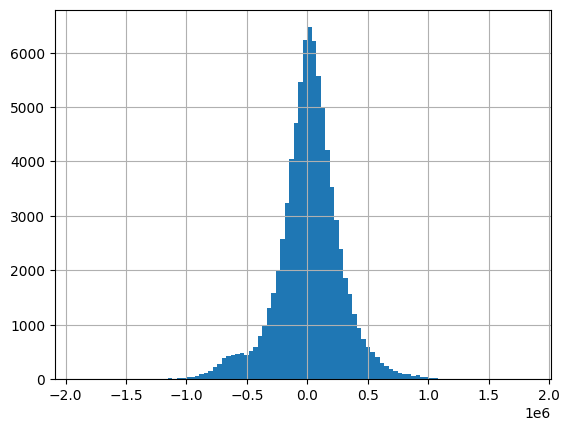

In [26]:
(a1m - b0m).hist(bins=100)
print((a1m - b0m).mean())

404967.25738048623


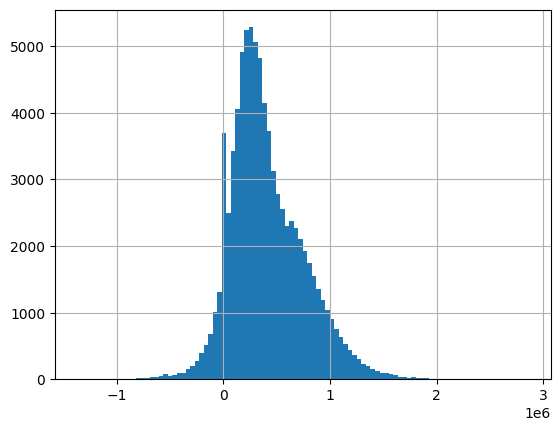

In [27]:
(a1m - a1m_hat).hist(bins=100)
print((a1m - a1m_hat).mean())

RV 추가 금액이 있는지 여부를 확인하기 어려운 이유, 다음과 같이 살펴볼 수 있다.

RV약정청구율==100인 경우, 다음달 이월 금액이 0이어야 한다. 하지만 아닌 경우도 존재함.

In [13]:
df[['잔액_리볼빙일시불이월_B0M', '잔액_리볼빙일시불이월_target', 'RV약정청구율']].head(20)

,잔액_리볼빙일시불이월_B0M,잔액_리볼빙일시불이월_target,RV약정청구율
0,1512611,1540264,20.912946
1,1139341,1073076,20.492362
2,1936044,1929447,19.625443
3,894886,928248,100.000000
4,1024403,1005488,22.855123
5,1251532,1309506,23.160342
6,1795668,1790685,20.525339
7,2140721,2018181,19.603756
8,1445991,1466367,20.433126
9,499272,527946,100.000000


In [28]:
(df['잔액_리볼빙일시불이월_target']==0).sum()

np.int64(2001)

<Axes: >

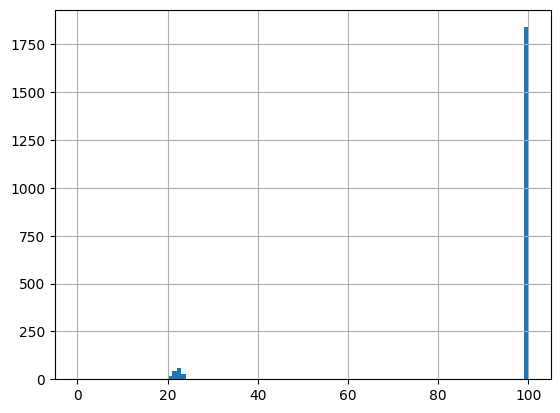

In [29]:
df.loc[df['잔액_리볼빙일시불이월_target']==0, 'RV약정청구율'].hist(bins=100)

In [31]:
(df.loc[df['잔액_리볼빙일시불이월_target']==0, 'RV약정청구율']==100).sum()

np.int64(1840)

---

현재 '상태'에 대한 분석

In [32]:
# difference between b0m and next month's balance
df['diff'] = a1m - b0m
df['diff_domain'] = a1m - a1m_hat

In [33]:
# calculate correlation
corr = df.corr(numeric_only=True)['diff'].sort_values(ascending=False)
corr_df = pd.DataFrame(corr)

In [34]:
corr_df.head(10)

,diff
diff,1.000000
diff_domain,0.672746
잔액_리볼빙일시불이월_target,0.448821
RV_최대잔액_R3M,0.145783
연체원금_B1M_B2M_ratio,0.137906
RV잔액이월횟수_R6M,0.124682
RV_최대잔액_R6M,0.116465
잔액_카드론_B0M_B1M_ratio,0.116068
잔액_일시불_B0M,0.100069
RV잔액이월횟수_R3M,0.097643


In [35]:
# calculate correlation
corr = df.corr(numeric_only=True)['diff_domain'].sort_values(ascending=False)
corr_df = pd.DataFrame(corr)
corr_df.head(10)

,diff_domain
diff_domain,1.000000
diff,0.672746
RV약정청구율,0.598151
RV신청일자,0.190262
이용금액_연체_R6M,0.167624
이용횟수_연체_R6M,0.156986
이용금액_연체_B0M,0.151549
이용금액_연체_R3M,0.150760
연체일수_B2M,0.147840
연체일수_B1M,0.147795


---

In [36]:
target

'잔액_리볼빙일시불이월_target'

In [37]:
df['RV신청일자_dt'] = pd.to_datetime(df['RV신청일자'], format='%Y%m%d', errors='coerce')
today = pd.to_datetime('2018-10-31')
df['RV신청일자_diff_days'] = (today - df['RV신청일자_dt']).dt.days

In [38]:
# calculate correlation
corr = df.corr(numeric_only=True)['잔액_리볼빙일시불이월_target'].sort_values(ascending=False)
corr_df = pd.DataFrame(corr)

In [39]:
corr_df.loc[~corr_df.index.str.contains('RV')].head(10)

,잔액_리볼빙일시불이월_target
잔액_리볼빙일시불이월_target,1.000000
잔액_리볼빙일시불이월_B0M,0.818783
잔액_일시불_B0M,0.564680
잔액_일시불_B2M,0.564474
잔액_일시불_B1M,0.563877
월중평잔_일시불,0.550431
월중평잔_일시불_B0M,0.550272
평잔_일시불_3M,0.531173
잔액_신판평균한도소진율_r3m,0.478611
잔액_B0M,0.450350


In [40]:
for i in df.columns:
    if pd.api.types.is_object_dtype(df[i]):
        print(i)

발급회원번호
연령
VIP등급코드
최상위카드등급코드
거주시도명
직장시도명
가입통신회사코드
Life_Stage
RV전환가능여부


In [46]:
output = plot_dataframe(df[['잔액_리볼빙일시불이월_B0M', '잔액_리볼빙일시불이월_target', '월중평잔_RV일시불', 'RV약정청구율', 'RV최소결제비율',
"잔액_일시불_B0M", "잔액_할부_B0M", "잔액_현금서비스_B0M", "잔액_리볼빙CA이월_B0M", '잔액_카드론_B0M', 
'잔액_신판평균한도소진율_r3m', '연체일수_B1M', '이용건수_신용_B0M', '연체원금_B1M', 'RV신청일자', '이용금액_해외', '이용금액_요식', '회원여부_연체', 'RV_평균잔액_R3M', 
'연체잔액_RV일시불_B0M', '이용금액_연체_B0M', '이용금액_일시불_B0M', '이용금액_신용_B0M', '카드이용한도금액', '연령', 'VIP등급코드', '최상위카드등급코드', 'Life_Stage']], color_column="잔액_리볼빙일시불이월_target",
save_dir="viz")

Dashboard created: viz\dashboard.html
Open this file in your browser to view all 37 plots


1. Preprocessing을 한 후 다시 시각화를 통해 살펴보기
2. 통계적인 방법을 통해 '통계적으로 유의미한' 변수를 선별하기 (categorical, numerical)
3. categorical
    - categorical 변수를 활용하여 target을 작은 group으로 나눈 후, 다른 변수들과의 관계를 확인 (stat 검증)
4. 파생변수 생성
    - 도메인 지식 활용
    - 통계적인 방법을 통해 생성


-> 생성할 파생 변수 list + 논리적인 근거

-> 가설 list

na values

In [ ]:
nas = pd.DataFrame(df.isna().sum())

In [ ]:
nas.loc[nas[0]>0]